# Stock Market EDA

In [3]:
# This block imports necessary libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import yfinance as yf

In [4]:
# This block downloads historical stock price data for selected tickers using yfinance.
tickers = ['AAPL', 'AMZN', 'BA', 'GOOG', 'IBM', 'MGM', 'T', 'TSLA', '^GSPC']

stocks_df = yf.download(tickers, start='2012-01-01', end='2025-01-01', auto_adjust=True)['Close']

stocks_df.rename(columns={'^GSPC': 'SP500'}, inplace=True)
stocks_df.reset_index(inplace=True)

stocks_df.head()

[*********************100%***********************]  9 of 9 completed


Ticker,Date,AAPL,AMZN,BA,GOOG,IBM,MGM,T,TSLA,SP500
0,2012-01-03,12.321683,8.9515,60.731102,16.438171,105.638786,10.493511,8.409145,1.872000,1277.060059
1,2012-01-04,12.387904,8.8755,60.821095,16.509071,105.207794,10.427399,8.422989,1.847333,1277.300049
2,2012-01-05,12.525434,8.8805,60.166504,16.280071,104.708771,10.512403,8.414687,1.808000,1281.060059
3,2012-01-06,12.656373,9.1305,60.534706,16.057983,103.506683,10.512403,8.375894,1.794000,1277.810059
4,2012-01-09,12.636296,8.9280,60.984749,15.377144,102.967972,10.691857,8.370255,1.816667,1280.699951


In [5]:
# Filling missing values.
stocks_df.ffill(inplace=True)

## Daily Returns

In [6]:
returns_df = stocks_df.copy()

for col in stocks_df.columns[1:]:
    returns_df[col] = stocks_df[col].pct_change()*100

returns_df.head()

Ticker,Date,AAPL,AMZN,BA,GOOG,IBM,MGM,T,TSLA,SP500
0,2012-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-01-04,0.537437,-0.849022,0.148182,0.431313,-0.407987,-0.630032,0.164625,-1.317683,0.018792
2,2012-01-05,1.110191,0.056336,-1.076256,-1.387117,-0.474322,0.815197,-0.098560,-2.129177,0.294372
3,2012-01-06,1.045389,2.815157,0.611972,-1.364170,-1.148029,0.000000,-0.461022,-0.774333,-0.253696
4,2012-01-09,-0.158630,-2.217835,0.743446,-4.239882,-0.520461,1.707077,-0.067314,1.263486,0.226160


## Summary Statistics

In [7]:
stocks_df.describe()

Ticker,Date,AAPL,AMZN,BA,GOOG,IBM,MGM,T,TSLA,SP500
count,3270,3270.000000,3270.000000,3270.000000,3270.000000,3270.000000,3270.000000,3270.000000,3270.000000,3270.000000
mean,2018-07-02 16:40:04.403669504,76.150021,81.162565,183.019688,68.235421,111.879422,27.626085,14.213667,90.848555,2963.239483
min,2012-01-03 00:00:00,11.874170,8.796500,55.668324,13.810674,70.321831,7.133005,8.229149,1.519333,1277.060059
25%,2015-04-06 06:00:00,23.185778,19.902125,116.773273,28.647266,97.936745,20.110992,11.927356,14.119500,2020.924988
50%,2018-07-02 12:00:00,41.492714,80.275501,167.870003,53.690205,107.080463,27.015709,14.630409,20.577666,2711.834961
75%,2021-09-29 18:00:00,138.897282,133.249996,225.160679,104.070585,115.192940,35.565891,15.823861,193.470005,3972.275085
max,2024-12-31 00:00:00,257.612701,232.929993,430.299957,197.252594,230.729034,50.900002,22.591267,479.859985,6090.270020
std,NaN,65.784034,60.036345,88.345486,46.436658,24.968265,10.223506,2.604571,110.017909,1196.749634


## Normalized Prices

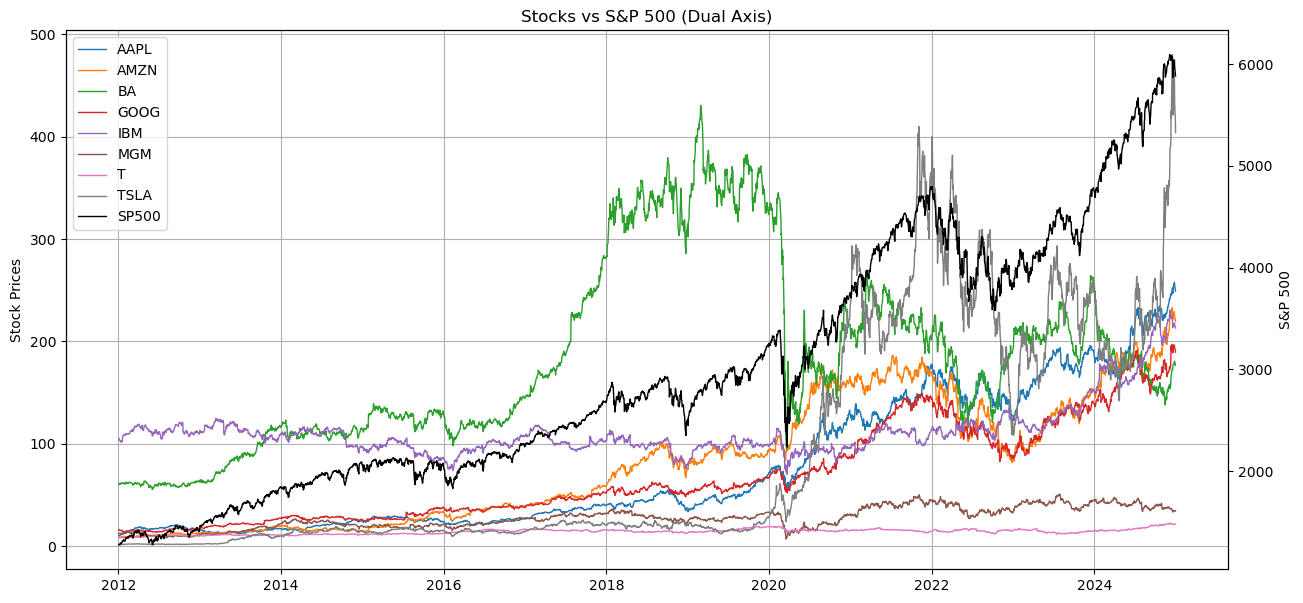

In [8]:
# This block visualizes stock price trends to compare performance over time.
def dual_axis_plot(df):
    fig, ax1 = plt.subplots(figsize=(15,7))

    # Left axis (Stocks)
    stocks = df.drop(columns=['Date', 'SP500'])
    for col in stocks.columns:
        ax1.plot(df['Date'], stocks[col], linewidth=1, label=col)

    ax1.set_ylabel('Stock Prices')
    ax1.grid()

    # Right axis (S&P 500)
    ax2 = ax1.twinx()
    ax2.plot(df['Date'], df['SP500'], color='black', linewidth=1, label='SP500')
    ax2.set_ylabel('S&P 500')

    # Title
    plt.title('Stocks vs S&P 500 (Dual Axis)')

    # Combine legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

    plt.show()

dual_axis_plot(stocks_df)

## Correlation Matrix

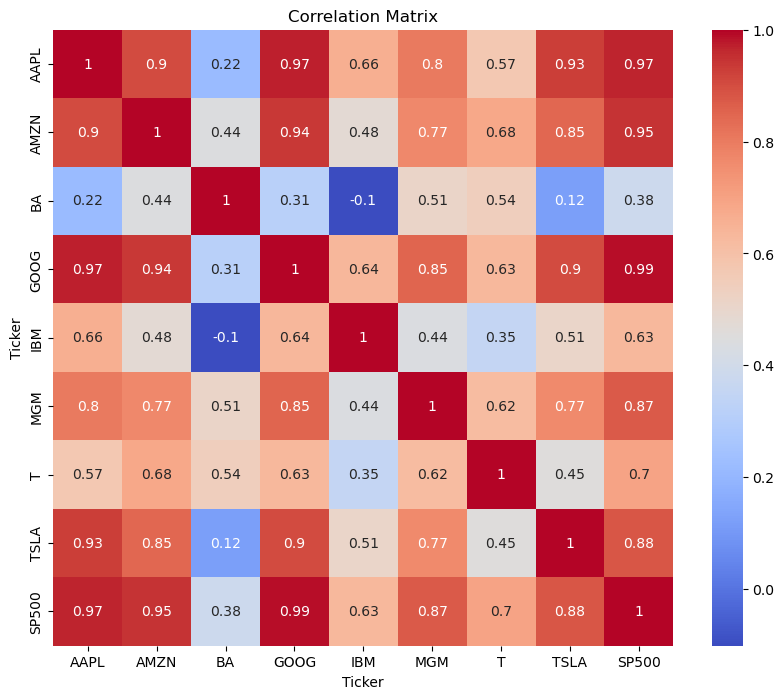

In [9]:
# This block computes the correlation between different stocks and visualizes it using a heatmap to show how their prices move relative to each other.
corr = stocks_df.drop(columns=['Date']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

## Volatility

In [10]:
# This block calculates volatility(standard deviation).
volatility = returns_df.drop(columns=['Date']).std()
print(volatility)

Ticker
AAPL     1.768366
AMZN     2.031206
BA       2.304458
GOOG     1.709165
IBM      1.416756
MGM      2.677685
T        1.328285
TSLA     3.600667
SP500    1.046809
dtype: float64


## SQL Insertion

In [17]:
SERVER   = r'LAPTOP-I272O7A3\SQLEXPRESS'
DATABASE = 'US_Stocks'

TICKERS = ['AAPL', 'AMZN', 'BA', 'GOOG', 'IBM', 'MGM', 'T', 'TSLA']
SP500   = '^GSPC'
START   = '2012-01-01'
END     = '2025-01-01'

COMPANY_MAP = {
    'AAPL': ('Apple Inc.',                'Technology'),
    'AMZN': ('Amazon.com Inc.',           'Consumer Discretionary'),
    'BA':   ('Boeing Company',            'Industrials'),
    'GOOG': ('Alphabet Inc.',             'Technology'),
    'IBM':  ('IBM Corporation',           'Technology'),
    'MGM':  ('MGM Resorts International', 'Consumer Discretionary'),
    'T':    ('AT&T Inc.',                 'Communication Services'),
    'TSLA': ('Tesla Inc.',                'Consumer Discretionary'),
}

BATCH_SIZE = 500   # rows per executemany call — keeps memory stable

# ── 2. CONNECT ─────────────────────────────────────────────────────────────────
print("Connecting to SQL Server...")
conn = pyodbc.connect(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={SERVER};"
    f"DATABASE={DATABASE};"
    f"Trusted_Connection=yes;"   # Windows Authentication
)
cursor = conn.cursor()
print("Connected.\n")

# ── 3. DOWNLOAD DATA ───────────────────────────────────────────────────────────
print("Downloading data from Yahoo Finance...")
all_tickers = TICKERS + [SP500]
raw = yf.download(all_tickers, start=START, end=END, auto_adjust=True)['Close']
raw.rename(columns={SP500: 'SP500'}, inplace=True)
raw.reset_index(inplace=True)
raw.ffill(inplace=True)
raw.dropna(inplace=True)
raw.reset_index(drop=True, inplace=True)
print(f"Downloaded {len(raw)} trading days.\n")

# ── 4. HELPER: batched executemany ─────────────────────────────────────────────
def insert_batches(sql, rows, label):
    total = len(rows)
    for i in range(0, total, BATCH_SIZE):
        batch = rows[i : i + BATCH_SIZE]
        cursor.executemany(sql, batch)
        conn.commit()
        print(f"  {label}: inserted {min(i + BATCH_SIZE, total)}/{total} rows")
    print(f"  ✓ {label} complete.\n")

# ── 5. DIM_DATE ────────────────────────────────────────────────────────────────
print("Inserting Dim_Date...")
dim_date_sql = """
    INSERT INTO Dim_Date (Date, Year, Month, Day, Quarter, Weekday)
    VALUES (?, ?, ?, ?, ?, ?)
"""
dim_date_rows = []
for dt in raw['Date']:
    d = pd.Timestamp(dt)
    dim_date_rows.append((
        d.date(), d.year, d.month, d.day, d.quarter, d.day_name()
    ))
insert_batches(dim_date_sql, dim_date_rows, "Dim_Date")

# ── 6. DIM_STOCK ───────────────────────────────────────────────────────────────
print("Inserting Dim_Stock...")
dim_stock_sql = """
    INSERT INTO Dim_Stock (Stock_Name, Company_Name, Sector)
    VALUES (?, ?, ?)
"""
dim_stock_rows = [
    (ticker, COMPANY_MAP[ticker][0], COMPANY_MAP[ticker][1])
    for ticker in TICKERS
]
insert_batches(dim_stock_sql, dim_stock_rows, "Dim_Stock")

# ── 7. FETCH STOCK_IDs ASSIGNED BY SQL SERVER ──────────────────────────────────
# We read back the auto-assigned IDENTITY values so we don't hardcode them.
cursor.execute("SELECT Stock_ID, Stock_Name FROM Dim_Stock")
stock_id_map = {row.Stock_Name: row.Stock_ID for row in cursor.fetchall()}
print(f"Stock ID map: {stock_id_map}\n")

# ── 8. FACT_STOCKPRICES ────────────────────────────────────────────────────────
print("Inserting Fact_StockPrices...")
fact_stock_sql = """
    INSERT INTO Fact_StockPrices (Date, Stock_ID, Close_Price, Daily_Return)
    VALUES (?, ?, ?, ?)
"""
fact_stock_rows = []
for i, row in raw.iterrows():
    d = pd.Timestamp(row['Date']).date()
    for ticker in TICKERS:
        stock_id = stock_id_map[ticker]
        close    = round(float(row[ticker]), 4)
        if i == 0:
            daily_ret = None   # NULL for the first row
        else:
            prev_close = raw.loc[i - 1, ticker]
            daily_ret  = round((row[ticker] - prev_close) / prev_close * 100, 6)
        fact_stock_rows.append((d, stock_id, close, daily_ret))
insert_batches(fact_stock_sql, fact_stock_rows, "Fact_StockPrices")

# ── 9. FACT_SP500 ──────────────────────────────────────────────────────────────
print("Inserting Fact_SP500...")
fact_sp500_sql = """
    INSERT INTO Fact_SP500 (Date, Close_Price, Daily_Return)
    VALUES (?, ?, ?)
"""
fact_sp500_rows = []
for i, row in raw.iterrows():
    d     = pd.Timestamp(row['Date']).date()
    close = round(float(row['SP500']), 4)
    if i == 0:
        daily_ret = None
    else:
        prev_close = raw.loc[i - 1, 'SP500']
        daily_ret  = round((row['SP500'] - prev_close) / prev_close * 100, 6)
    fact_sp500_rows.append((d, close, daily_ret))
insert_batches(fact_sp500_sql, fact_sp500_rows, "Fact_SP500")

# ── 10. DONE ───────────────────────────────────────────────────────────────────
cursor.close()
conn.close()
print("All done! Database US_Stocks is fully loaded.")

Connecting to SQL Server...
Connected.



[*********************100%***********************]  9 of 9 completed


Downloaded 3270 trading days.

Inserting Dim_Date...
  Dim_Date: inserted 500/3270 rows
  Dim_Date: inserted 1000/3270 rows
  Dim_Date: inserted 1500/3270 rows
  Dim_Date: inserted 2000/3270 rows
  Dim_Date: inserted 2500/3270 rows
  Dim_Date: inserted 3000/3270 rows
  Dim_Date: inserted 3270/3270 rows
  ✓ Dim_Date complete.

Inserting Dim_Stock...
  Dim_Stock: inserted 8/8 rows
  ✓ Dim_Stock complete.

Stock ID map: {'AAPL': 1, 'AMZN': 2, 'BA': 3, 'GOOG': 4, 'IBM': 5, 'MGM': 6, 'T': 7, 'TSLA': 8}

Inserting Fact_StockPrices...
  Fact_StockPrices: inserted 500/26160 rows
  Fact_StockPrices: inserted 1000/26160 rows
  Fact_StockPrices: inserted 1500/26160 rows
  Fact_StockPrices: inserted 2000/26160 rows
  Fact_StockPrices: inserted 2500/26160 rows
  Fact_StockPrices: inserted 3000/26160 rows
  Fact_StockPrices: inserted 3500/26160 rows
  Fact_StockPrices: inserted 4000/26160 rows
  Fact_StockPrices: inserted 4500/26160 rows
  Fact_StockPrices: inserted 5000/26160 rows
  Fact_StockPrice